# SEIRS-SEI Malaria Model for Manaus - Epigrass Implementation

This notebook implements a custom SEIRS-SEI model for malaria transmission in Manaus, Brazil, using Epigrass framework with climate integration.

## Model Structure
- **Human (SEIRS)**: Susceptible -> Exposed -> Infectious -> Recovered -> Susceptible
- **Vector (SEI)**: Susceptible -> Exposed -> Infectious

## Data Sources
- Climate: temperature, precipitation, humidity (2016-2024)
- Population: IBGE population data for Manaus
- Observed cases: SIVEP-Malaria notifications

In [2]:
import os
os.getcwd()

'C:\\Users\\rapha\\Study_on_malaria_dynamics_v2\\epigrass\\notebooks'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# sys.path.insert(0, '/mnt/c/Users/rapha/epigrass')
# sys.path.insert(0, '/mnt/c/Users/rapha/epigrass/seirs_sei_repo/epigrass_tests')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Load Data

In [5]:
DATA_DIR = '../../data_files/data'

climate_data = pd.read_csv(DATA_DIR + '/climate_api_data_2016_2024.csv')
cases_data = pd.read_csv(DATA_DIR + '/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv')

pop_data = pd.read_csv(DATA_DIR + '/ibge_manaus_population_data_2016_2024.csv')
pop_data.rename(columns={'index': 'date'}, inplace=True)

defor_data = pd.read_csv(DATA_DIR + '/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')
fires_data = pd.read_csv(DATA_DIR + '/inpe_fire_counts_data_2016_2024.csv')

climate_data['date'] = pd.to_datetime(climate_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])
pop_data['date'] = pd.to_datetime(pop_data['date'])
defor_data['date'] = pd.to_datetime(defor_data['date'])
fires_data['date'] = pd.to_datetime(fires_data['date'])

# Filter data to 2017-01-01 to 2023-12-31
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2023-12-31')
climate_data = climate_data[(climate_data['date'] >= start_date) & (climate_data['date'] <= end_date)].reset_index(drop=True)
cases_data = cases_data[(cases_data['date'] >= start_date) & (cases_data['date'] <= end_date)].reset_index(drop=True)
pop_data = pop_data[(pop_data['date'] >= start_date) & (pop_data['date'] <= end_date)].reset_index(drop=True)
defor_data = defor_data[(defor_data['date'] >= start_date) & (defor_data['date'] <= end_date)].reset_index(drop=True)
fires_data = fires_data[(fires_data['date'] >= start_date) & (fires_data['date'] <= end_date)].reset_index(drop=True)

print("Data loaded and filtered successfully!")
print("Climate data:", len(climate_data), "days")
print("Cases data:", len(cases_data), "days")
print("Pop data:", len(pop_data), "days")
print("Deforestation data:", len(defor_data), "days")
print("Forest fires data:", len(fires_data), "days")

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 2556 days
Forest fires data: 2556 days


## Climate Integration Functions

In [7]:
def get_climate_params(climate_df, day_index):    
    if day_index >= len(climate_df):        
        day_index = len(climate_df) - 1    
    if day_index < 0:        
        day_index = 0    
    row = climate_df.iloc[day_index]    
    return {'temp_min': row['temp_min'],
            'temp_med': row['temp_med'],
            'temp_max': row['temp_max'],
            'precip_med': row['precip_med'],
            'precip_tot': row['precip_tot'],
            'umid_med': row['umid_med']}

def temperature_dependent_biting_rate(T, T_min=15, T_opt=27, T_max=35):    
    if T < T_min or T > T_max:        
        return 0    
    sigma = (T_max - T_min) / 2    
    return np.exp(-((T - T_opt) ** 2) / (2 * sigma ** 2))

def temperature_dependent_mortality(T, T_ref=25, Q=0.005):    
    return (1/30) * np.exp(Q * (T - T_ref))

def precipitation_dependent_mosquito_capacity(P, baseline=100, threshold=5):    
    if P < threshold:        
        return baseline * 0.3    
    return baseline * min(2.0, 0.3 + P / 50)

def temperature_dependent_incubation(T):    
    if T < 15:        
        return 30    
    elif T > 35:        
        return 8    
    else:        
        return 15 - 0.25 * (T - 15)

## SEIRS-SEI Model Implementation

In [9]:
class SEIRS_SEI_Model:    
    def __init__(self, N, M0, climate_data, defor_data=None, fires_data=None, params=None):        
        self.N = N        
        self.M0 = M0        
        self.climate_data = climate_data        
        self.defor_data = defor_data        
        self.fires_data = fires_data        
        self.params = params or {'b2': 0.5, 'b1': 0.5, 'sigma_h': 1/10, 
                                 'gamma': 1/60, 'omega': 1/365, 'r_h': 0.00005, 
                                 'tau_H': 10, #'tau_M': 12, 
                                 'defor_delay': 14, 'fire_delay': 21}        
        self._history = {}        
        self._history_length = 3650            
        
    def get_defor_params(self, day_index):        
        if self.defor_data is not None:            
            idx = min(day_index, len(self.defor_data) - 1)            
            return self.defor_data.iloc[idx]['total_degradation']        
        return 0       
        
    def get_fire_params(self, day_index):        
        if self.fires_data is not None:            
            idx = min(day_index, len(self.fires_data) - 1)            
            return self.fires_data.iloc[idx]['fire_counts']        
        return 0       
    
    def _a_with_fire(self, T, fire_counts):        
        base_rate = self._a_base(T)        
        fire_intensity = min(fire_counts / 50.0, 1.0)        
        smoke_reduction = 0.4 * fire_intensity        
        return base_rate * (1 - smoke_reduction)       
        
    def _a_base(self, T):        
        T_prime = 25.6        
        D1 = 4.0        
        a_val = max(0, (T - T_prime) / D1)        
        return min(a_val, 0.8)       
        
    def _mu_with_fire(self, T, U, fire_counts):        
        base_mu = self._mu_base(T, U)        
        fire_intensity = min(fire_counts / 50.0, 1.0)        
        fire_mortality_increase = 0.15 * fire_intensity        
        return min(base_mu + fire_mortality_increase, 0.5)       
        
    def _mu_base(self, T, U):        
        A = 12.5        
        B = 15.0        
        C = -48.78        
        denom = A * T**2 + B * T + C        
        if denom >= 0:            
            p_T_temp = 0.85        
        else:            
            p_T_temp = np.exp(-1.0 / denom)        
        if U < 50:            
            p_U = 0.0        
        elif U < 60:            
            p_U = (U - 50) / 10.0        
        else:            
            p_U = 1.0        
            
        p_T_val = p_T_temp * p_U        
        if p_T_val <= 0:            
            return 0.15        
        return min(-np.log(p_T_val), 0.3)       
        
    def _tau_M(self, T):        
        DD = 105.0        
        Tmin = 14.5        
        if T <= Tmin:            
            return 50.0        
        return DD / (T - Tmin)       
        
    def _b_rate(self, R, T, R_L, total_defor, fire_counts):        
        BE = 200.0        
        p_ME = 0.5        
        p_ML = 0.5        
        p_MP = 0.5        
        tau_E = 1.0        
        tau_L = 10.0        
        tau_P = 1.0        
        if R < 0 or R > R_L:            
            p_ER = 0.0        
            p_LR = 0.0
            p_PR = 0.0 
        else:            
            p_ER = (4.0 * p_ME / R_L**2) * R * (R_L - R)   
            p_LR = (4.0 * p_ML / R_L**2) * R * (R_L - R)
            p_PR = (4.0 * p_MP / R_L**2) * R * (R_L - R)
        c1 = 0.00554        
        c2 = -0.06737        
        p_LT = np.exp(-max(c1 * T + c2, -10))        
        numerator = BE * p_ER * p_LR * p_LT * p_PR        
        denominator = tau_E + tau_L + tau_P        
        base_rate = numerator / denominator if denominator > 0 else 0        
        defor_max_effect = 0.3        
        defor_scale = 0.0001        
        fire_habitat_effect = 0.2        
        defor_effect = min(total_defor * defor_scale, defor_max_effect)        
        fire_intensity = min(fire_counts / 50.0, 1.0)        
        fire_habitat_destruction = fire_habitat_effect * fire_intensity        
        net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)        
        return base_rate * net_effect       
        
    def _get_delayed_state(self, t, delay):        
        tau_safe = min(max(delay, 1), 100)        
        delayed_t = t - tau_safe        
        if delayed_t <= 0:            
            return self._history.get(0)        
        idx = int(delayed_t)        
        frac = delayed_t - idx        
        if frac < 1e-9:            
            return self._history.get(idx)        
        state_low = self._history.get(idx)        
        state_high = self._history.get(idx + 1)        
        if state_low is None and state_high is None:            
            return None        
        if state_low is None:            
            return state_high        
        if state_high is None:            
            return state_low        
        return [state_low[i] + frac * (state_high[i] - state_low[i]) for i in range(len(state_low))]       
        
    def get_params_t(self, t):        
        day_index = int(t) % len(self.climate_data)        
        climate = get_climate_params(self.climate_data, day_index)        
        T = climate["temp_med"]        
        P = climate["precip_med"]        
        U = climate["umid_med"]                
        defor_km2 = self.get_defor_params(day_index)        
        fire_count = self.get_fire_params(day_index)                
        tau_H = self.params.get('tau_H', 10)        
        defor_delay = self.params.get('defor_delay', 14)        
        fire_delay = self.params.get('fire_delay', 21)                
        delayed_defor = self.get_defor_params(day_index - defor_delay) if day_index > defor_delay else defor_km2        
        delayed_fire = self.get_fire_params(day_index - fire_delay) if day_index > fire_delay else fire_count                
        a = self._a_with_fire(T, fire_count)        
        mu = self._mu_with_fire(T, U, fire_count)        
        tau_m = self._tau_M(T)                
        R_L = 32.67        
        temp_factor = max(0.1, min(1, (T - 15) / 15))        
        rain_factor = min(1, max(0, P / R_L))        
        day_of_year = int(t % 365.25)        
        seasonal_phase = 2 * np.pi * (day_of_year - 180) / 365.25        
        seasonal_factor = 2.5 + 2.0 * np.sin(seasonal_phase)                
        M = self.M0        
        defor_max_effect = 0.3        
        defor_scale = 0.0001        
        fire_habitat_effect = 0.2        
        defor_cap_factor = 1 + min(delayed_defor * defor_scale, defor_max_effect)        
        fire_cap_factor = 1 - (fire_habitat_effect * min(delayed_fire / 50.0, 1.0))        
        env_cap_factor = defor_cap_factor * max(fire_cap_factor, 0.3)        
        K = M * temp_factor * rain_factor * seasonal_factor * env_cap_factor                
        return {"a": a, "mu": mu, "tau_m": tau_m, "K": K, "T": T, 
                "P": P, "U": U, "defor": defor_km2, "fires": fire_count, 
                "delayed_defor": delayed_defor, "delayed_fire": delayed_fire}            
        
    def derivatives(self, t, y):        
        S_h, E_h, I_h, R_h, S_m, E_m, I_m = y        
        N = S_h + E_h + I_h + R_h                
        self._history[int(t)] = [S_h, E_h, I_h, R_h, S_m, E_m, I_m]        
        if len(self._history) > self._history_length:            
            oldest_keys = sorted(self._history.keys())[: len(self._history) - self._history_length]            
            for k in oldest_keys:                
                del self._history[k]                
        S_h = max(S_h, 1e-6)        
        E_h = max(E_h, 1e-6)        
        I_h = max(I_h, 1e-6)        
        R_h = max(R_h, 1e-6)        
        S_m = max(S_m, 1e-6)        
        E_m = max(E_m, 1e-6)        
        I_m = max(I_m, 1e-6)                
        p = self.get_params_t(t)        
        b2 = self.params['b2']        
        b1 = self.params['b1']        
        sigma_h = self.params['sigma_h']        
        gamma = self.params['gamma']        
        omega = self.params['omega']        
        r_h = self.params['r_h']        
        tau_H = self.params.get('tau_H', 10)                
        defor_max_effect = 0.3        
        defor_scale = 0.0001        
        defor_exposure_factor = 1 + min(p['delayed_defor'] * defor_scale, defor_max_effect)   
        
        foi_h = p['a'] * b2 * (I_m / N) * defor_exposure_factor        
        new_exposures_h = foi_h * S_h                
        tau_H_safe = min(max(tau_H, 1), 30)        
        delayed_state_h = self._get_delayed_state(t, tau_H_safe)        
        if delayed_state_h is not None:            
            S_H_delay = max(delayed_state_h[0], 1e-6)            
            I_M_delay = max(delayed_state_h[6], 1e-6)        
        else:            
            S_H_delay = S_h            
            I_M_delay = I_m    
            
        foi_h_delay = p['a'] * b2 * (I_M_delay / N) * defor_exposure_factor        
        new_infections_h = foi_h_delay * S_H_delay                
        recoveries = gamma * I_h        
        immunity_loss = omega * R_h    
        
        dS_h = r_h * N - new_exposures_h + immunity_loss        
        dE_h = new_exposures_h - new_infections_h        
        dI_h = new_infections_h - recoveries        
        dR_h = recoveries - immunity_loss                
        
        foi_m = p['a'] * b1 * (I_h / N)        
        new_exposures_m = foi_m * S_m                
        tau_M_safe = min(max(p['tau_m'], 1), 50)        
        delayed_state_m = self._get_delayed_state(t, tau_M_safe)        
        if delayed_state_m is not None:            
            S_M_delay = max(delayed_state_m[4], 1e-6)            
            I_H_delay_M = max(delayed_state_m[2], 1e-6)        
        else:            
            S_M_delay = S_m            
            I_H_delay_M = I_h             
            
        l_curr = np.exp(-p['mu'] * tau_M_safe)        
        foi_m_delay = p['a'] * b1 * (I_H_delay_M / N)        
        new_infections_m = foi_m_delay * S_M_delay * l_curr                
        R_L = 32.67           
        b_curr = self._b_rate(p['P'], p['T'], R_L, p['delayed_defor'], p['delayed_fire'])        
        total_mosquitoes = S_m + E_m + I_m        
        density_factor = max(0, 1 - total_mosquitoes / p['K']) if p['K'] > 0 else 0        
        mosquito_birth = b_curr * density_factor * p['K']                
        
        dS_m = mosquito_birth - new_exposures_m - p['mu'] * S_m        
        dE_m = new_exposures_m - new_infections_m - p['mu'] * E_m        
        dI_m = new_infections_m - p['mu'] * I_m                
        
        dS_h = max(dS_h, -S_h / 10)        
        dE_h = max(dE_h, -E_h / 10)        
        dI_h = max(dI_h, -I_h / 10)        
        dR_h = max(dR_h, -R_h / 10)        
        dS_m = max(dS_m, -S_m / 10)        
        dE_m = max(dE_m, -E_m / 10)        
        dI_m = max(dI_m, -I_m / 10)                
        
        return [dS_h, dE_h, dI_h, dR_h, dS_m, dE_m, dI_m]            
        
    def run(self, t_span, y0, method='RK45'):        
        self._history = {}        
        t_eval = np.linspace(0, t_span, t_span + 1)        
        sol = solve_ivp(self.derivatives, (0, t_span), y0, method=method, t_eval=t_eval, dense_output=True)        
        return sol

## Run Simulation

In [11]:
INITIAL_POP_MANAUS = 8558 #pop_data['ADJUSTED_POPULATION'].iloc[0] #8558 #2182000
INITIAL_MOSQUITOES = 100000 #500
I0 = float(cases_data['active_total'].iloc[0]) #50
E0 = I0 * 0.5 #100
R0 = 0
S0 = INITIAL_POP_MANAUS - I0 - E0 - R0
S_m0 = 0.8 * INITIAL_MOSQUITOES
E_m0 = 0.1 * INITIAL_MOSQUITOES
I_m0 = 0.1 * INITIAL_MOSQUITOES
y0 = [S0, E0, I0, R0, S_m0, E_m0, I_m0]
params = {'b2': 0.3, 'b1': 0.3, 'sigma_h': 1/10, 'gamma': 1/180, 'omega': 1/180, 'r_h': 0.00005,} 
#{'b2': 0.3, 'b1': 0.3, 'sigma_h': 1/12, 'gamma': 1/180, 'omega': 1/180, 'r_h': 0,} 
#{'b2': 0.5, 'b1': 0.5, 'sigma_h': 1/10, 'gamma': 1/60, 'omega': 1/365, 'r_h': 0.00005,}
model = SEIRS_SEI_Model(INITIAL_POP_MANAUS, INITIAL_MOSQUITOES, climate_data, defor_data, fires_data, params)
SIMULATION_DAYS = 2556
print("Running simulation for", SIMULATION_DAYS, "days...")
sol = model.run(SIMULATION_DAYS, y0)
print("Simulation completed!")

Running simulation for 2556 days...
Simulation completed!


In [12]:
t = sol.t
S_h, E_h, I_h, R_h, S_m, E_m, I_m = sol.y
print("t shape:", t.shape)
print("y shape:", sol.y.shape)

t shape: (2557,)
y shape: (7, 2557)


## Visualize Results

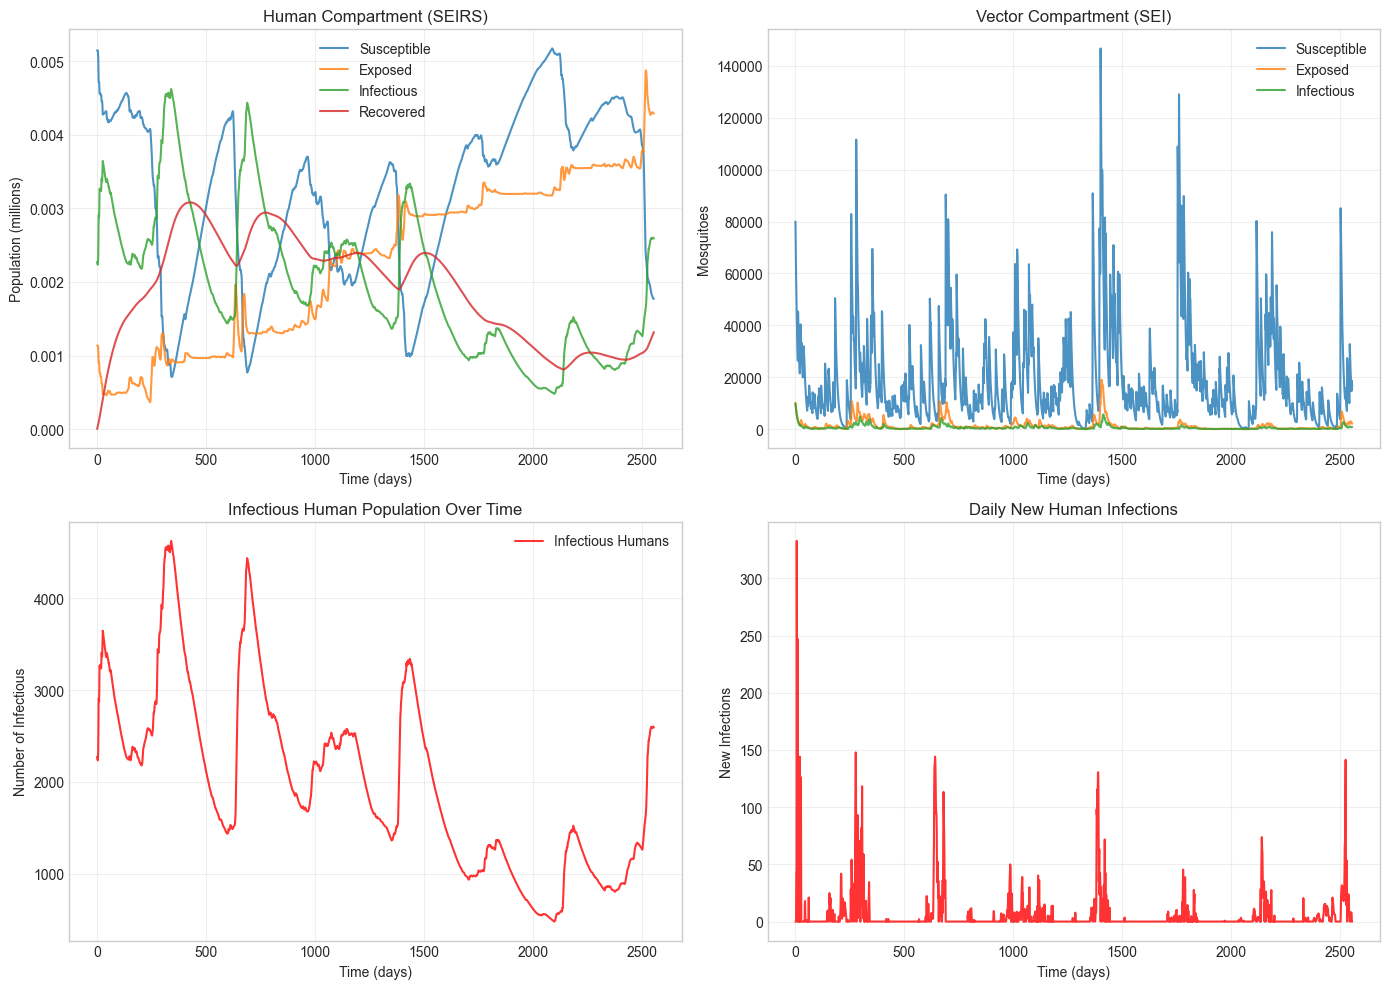

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0, 0]
ax1.plot(t, S_h/1e6, label="Susceptible", alpha=0.8)
ax1.plot(t, E_h/1e6, label="Exposed", alpha=0.8)
ax1.plot(t, I_h/1e6, label="Infectious", alpha=0.8)
ax1.plot(t, R_h/1e6, label="Recovered", alpha=0.8)
# ax1.plot(t, S_h/1e6, "b-", label="Susceptible", alpha=0.8)
# ax1.plot(t, E_h/1e6, "orange", label="Exposed", alpha=0.8)
# ax1.plot(t, I_h/1e6, "r-", label="Infectious", alpha=0.8)
# ax1.plot(t, R_h/1e6, "g-", label="Recovered", alpha=0.8)
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Population (millions)")
ax1.set_title("Human Compartment (SEIRS)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(t, S_m, label="Susceptible", alpha=0.8)
ax2.plot(t, E_m, label="Exposed", alpha=0.8)
ax2.plot(t, I_m, label="Infectious", alpha=0.8)
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Mosquitoes")
ax2.set_title("Vector Compartment (SEI)")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(t, I_h, "r-", label="Infectious Humans", alpha=0.8)
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Number of Infectious")
ax3.set_title("Infectious Human Population Over Time")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
new_infections_h = np.diff(np.insert(I_h, 0, I_h[0]))
new_infections_h = np.maximum(new_infections_h, 0)
ax4.plot(t, new_infections_h, "r-", alpha=0.8)
ax4.set_xlabel("Time (days)")
ax4.set_ylabel("New Infections")
ax4.set_title("Daily New Human Infections")
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Compare with Observed Data

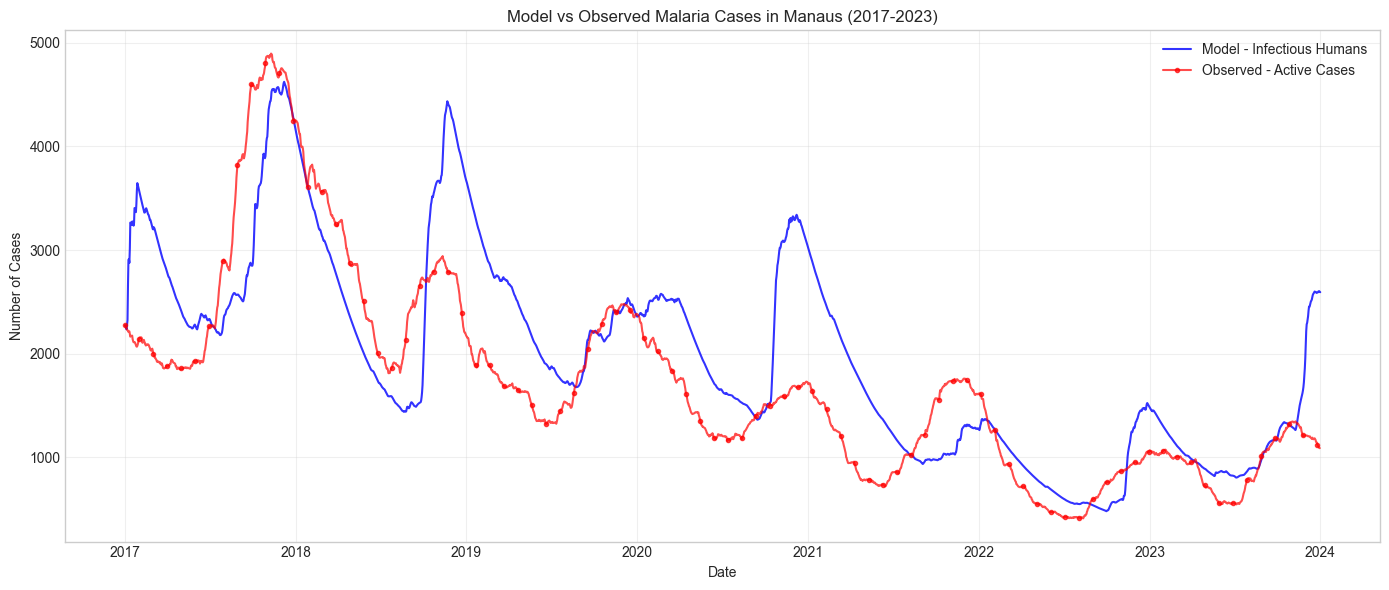

In [16]:
start_date = pd.to_datetime('2017-01-01')
sim_dates = pd.date_range(start=start_date, periods=len(t), freq='D')
fig, ax = plt.subplots(figsize=(14, 6))# Combine model infectious with observed cases
ax.plot(sim_dates, I_h, 'b-', label='Model - Infectious Humans', alpha=0.8)
ax.plot(cases_data['date'], cases_data['active_total'], 'r-', label='Observed - Active Cases', alpha=0.7, marker='o', markersize=3, markevery=30)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Cases')
ax.set_title('Model vs Observed Malaria Cases in Manaus (2017-2023)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
mse = np.mean((cases_data['active_total'].values - I_h[1:])**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(cases_data['active_total'].values - I_h[1:]))

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

MSE: 451988.32898638863
RMSE: 672.3007727099447
MAE: 515.1911815861343


Running previous model for comparison...
Previous model completed!


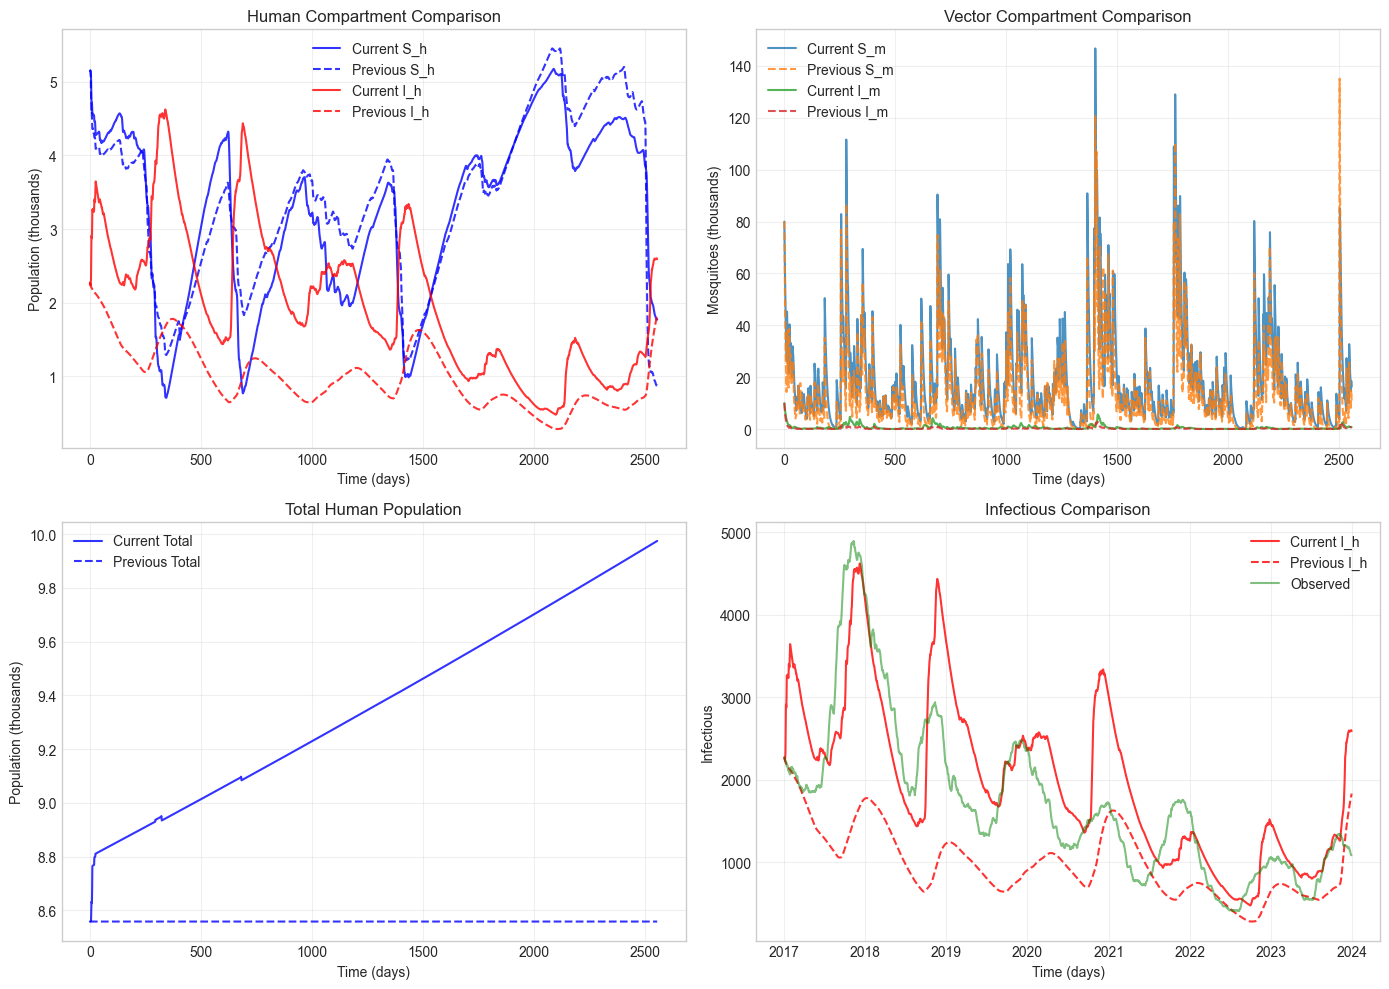


=== Final values comparison ===
Current model - S_h: 1772, I_h: 2593, Total: 9975
Previous model - S_h: 878, I_h: 1834, Total: 8558


In [18]:
### Compare with commented (previous) model

# Prepare climate interpolation functions from the data
temp_func = interp1d(range(len(climate_data)), climate_data['temp_med'].values, kind='linear', fill_value='extrapolate')
precip_func = interp1d(range(len(climate_data)), climate_data['precip_med'].values, kind='linear', fill_value='extrapolate')
umid_func = interp1d(range(len(climate_data)), climate_data['umid_med'].values, kind='linear', fill_value='extrapolate')
fire_func = interp1d(range(len(fires_data)), fires_data['fire_counts'].values, kind='linear', fill_value='extrapolate')
defor_func = interp1d(range(len(defor_data)), defor_data['total_degradation'].values, kind='linear', fill_value='extrapolate')

# Previous model parameters
prev_params = {
    'b1': 0.5,
    'b2': 0.5,
    'gamma': 0.01,
    'r_H': 0.00005,
    'omega': 1/365,
    'tau_H': 12,
    'R_L': 32.67,
    'M': 100000.0,
    'pME': 0.5,
    'pML': 0.5,
    'pMP': 0.5,
}

# Simple version of previous model for comparison
def prev_derivatives(t, y):
    S_H, E_H, I_H, R_H, S_M, E_M, I_M = y
    N = S_H + E_H + I_H + R_H
    
    T = float(temp_func(t))
    R = float(precip_func(t))
    U = float(umid_func(t))
    fire_counts = float(fire_func(t))
    total_defor = float(defor_func(t))
    
    # Temperature dependent parameters
    T_prime = 25.6
    D1 = 4.0
    a_curr = min(max((T - T_prime) / D1, 0), 0.8)
    
    # Fire effect on biting rate
    fire_intensity = min(fire_counts / 50.0, 1.0)
    a_curr = a_curr * (1 - 0.4 * fire_intensity)
    
    # Mosquito mortality
    A, B, C = 12.5, 15.0, -48.78
    denom = A * T**2 + B * T + C
    p_T_temp = 0.85 if denom >= 0 else np.exp(-1.0 / denom)
    p_U = 0.0 if U < 50 else ((U - 50) / 10.0 if U < 60 else 1.0)
    p_T_val = p_T_temp * p_U
    mu_curr = min(-np.log(p_T_val) if p_T_val > 0 else 0.15, 0.3)
    
    # Fire effect on mortality
    mu_curr = min(mu_curr + 0.15 * fire_intensity, 0.5)
    
    # Carrying capacity
    temp_factor = max(0.1, min(1, (T - 15) / 15))
    rain_factor = min(1, max(0, R / 32.67))
    day_of_year = int(t % 365.25)
    seasonal_factor = 2.5 + 2.0 * np.sin(2 * np.pi * (day_of_year - 180) / 365.25)
    
    defor_max_effect = 0.3
    defor_scale = 0.0001
    fire_habitat_effect = 0.2
    defor_cap_factor = 1 + min(total_defor * defor_scale, defor_max_effect)
    fire_cap_factor = 1 - (fire_habitat_effect * min(fire_counts / 50.0, 1.0))
    K = 100000 * temp_factor * rain_factor * seasonal_factor * defor_cap_factor * max(fire_cap_factor, 0.3)
    
    # Mosquito recruitment
    BE, tau_E, tau_L, tau_P = 200.0, 1.0, 10.0, 1.0
    c1, c2 = 0.00554, -0.06737
    p_LT = np.exp(-max(c1 * T + c2, -10))
    p_ER = (4 * 0.5 / 32.67**2) * R * (32.67 - R) if 0 <= R <= 32.67 else 0
    p_LR = (4 * 0.5 / 32.67**2) * R * (32.67 - R) if 0 <= R <= 32.67 else 0
    p_PR = (4 * 0.5 / 32.67**2) * R * (32.67 - R) if 0 <= R <= 32.67 else 0
    b_curr = BE * p_ER * p_LR * p_LT * p_PR / (tau_E + tau_L + tau_P) if (tau_E + tau_L + tau_P) > 0 else 0
    
    total_mosquitoes = S_M + E_M + I_M
    density_factor = max(0, 1 - total_mosquitoes / K) if K > 0 else 0
    mosquito_birth = b_curr * density_factor * K
    
    # Force of infection
    b1, b2, gamma = 0.5, 0.5, 0.01
    omega = 1/365
    r_H = 0
    
    # Previous model uses current I_M for both foi calculation
    defor_exposure_factor = 1 + min(total_defor * 0.0001, 0.3)
    foi_human = a_curr * b2 * (I_M / N) * defor_exposure_factor
    
    new_exposures_H = foi_human * S_H
    new_infections_H = gamma * E_H  # Simplified - uses gamma directly
    recoveries = gamma * I_H
    immunity_loss = omega * R_H
    
    dS_H = r_H * N - new_exposures_H + immunity_loss
    dE_H = new_exposures_H - new_infections_H
    dI_H = new_infections_H - recoveries
    dR_H = recoveries - immunity_loss
    
    # Mosquito
    foi_mosquito = a_curr * b1 * (I_H / N)
    new_exposures_M = foi_mosquito * S_M
    
    # Previous model uses DD for sporogonic cycle
    tau_M = 105.0 / max(T - 14.5, 1) if T > 14.5 else 50
    l_curr = np.exp(-mu_curr * tau_M)
    new_infections_M = a_curr * b1 * (I_H / N) * S_M * l_curr
    
    dS_M = mosquito_birth - new_exposures_M - mu_curr * S_M
    dE_M = new_exposures_M - new_infections_M - mu_curr * E_M
    dI_M = new_infections_M - mu_curr * I_M
    
    return [dS_H, dE_H, dI_H, dR_H, dS_M, dE_M, dI_M]

# Run previous model
print("Running previous model for comparison...")
sol_prev = solve_ivp(prev_derivatives, (0, 2556), y0, method='RK45', t_eval=np.linspace(0, 2556, 2557), dense_output=True)
S_h_prev, E_h_prev, I_h_prev, R_h_prev, S_m_prev, E_m_prev, I_m_prev = sol_prev.y
print("Previous model completed!")

# Compare results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(t, S_h/1000, 'b-', label='Current S_h', alpha=0.8)
ax1.plot(t, S_h_prev/1000, 'b--', label='Previous S_h', alpha=0.8)
ax1.plot(t, I_h/1000, 'r-', label='Current I_h', alpha=0.8)
ax1.plot(t, I_h_prev/1000, 'r--', label='Previous I_h', alpha=0.8)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Population (thousands)')
ax1.set_title('Human Compartment Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(t, S_m/1000, '-', label='Current S_m', alpha=0.8)
ax2.plot(t, S_m_prev/1000, '--', label='Previous S_m', alpha=0.8)
ax2.plot(t, I_m/1000, '-', label='Current I_m', alpha=0.8)
ax2.plot(t, I_m_prev/1000, '--', label='Previous I_m', alpha=0.8)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Mosquitoes (thousands)')
ax2.set_title('Vector Compartment Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(t, (S_h + E_h + I_h + R_h)/1000, 'b-', label='Current Total', alpha=0.8)
ax3.plot(t, (S_h_prev + E_h_prev + I_h_prev + R_h_prev)/1000, 'b--', label='Previous Total', alpha=0.8)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Population (thousands)')
ax3.set_title('Total Human Population')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(sim_dates, I_h, 'r-', label='Current I_h', alpha=0.8)
ax4.plot(sim_dates, I_h_prev, 'r--', label='Previous I_h', alpha=0.8)
ax4.plot(cases_data['date'], cases_data['active_total'], 'g-', label='Observed', alpha=0.5)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Infectious')
ax4.set_title('Infectious Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Final values comparison ===")
print(f"Current model - S_h: {S_h[-1]:.0f}, I_h: {I_h[-1]:.0f}, Total: {S_h[-1]+E_h[-1]+I_h[-1]+R_h[-1]:.0f}")
print(f"Previous model - S_h: {S_h_prev[-1]:.0f}, I_h: {I_h_prev[-1]:.0f}, Total: {S_h_prev[-1]+E_h_prev[-1]+I_h_prev[-1]+R_h_prev[-1]:.0f}")


## Summary Statistics

In [20]:
print("Model run completed!")
print("Human population (N):", INITIAL_POP_MANAUS)
print("Initial mosquitoes:", INITIAL_MOSQUITOES)
print()
print("Final state (day", int(t[-1]), ")")
print("  Susceptible (S_h):", S_h[-1])
print("  Exposed (E_h):", E_h[-1])
print("  Infectious (I_h):", I_h[-1])
print("  Recovered (R_h):", R_h[-1])
print()
print("  Susceptible mosquitoes (S_m):", S_m[-1])
print("  Exposed mosquitoes (E_m):", E_m[-1])
print("  Infectious mosquitoes (I_m):", I_m[-1])
print()
print("Observed data:")
print("  Date range:", cases_data["date"].min().date(), "to", cases_data["date"].max().date())
print("  Mean active cases:", cases_data["active_total"].mean())
print("  Max active cases:", cases_data["active_total"].max())
print("  Min active cases:", cases_data["active_total"].min())

Model run completed!
Human population (N): 8558
Initial mosquitoes: 100000

Final state (day 2556 )
  Susceptible (S_h): 1771.5139718464472
  Exposed (E_h): 4289.776795656436
  Infectious (I_h): 2593.2888472457707
  Recovered (R_h): 1319.9812565015

  Susceptible mosquitoes (S_m): 16341.037854080472
  Exposed mosquitoes (E_m): 2044.6017451761945
  Infectious mosquitoes (I_m): 769.3372195014331

Observed data:
  Date range: 2017-01-01 to 2023-12-31
  Mean active cases: 1738.8243348982785
  Max active cases: 4897
  Min active cases: 410


In [21]:
# class SEIRS_SEI(ContinuousModel):
#     """
#     SEIRS-SEI Vector-Borne Disease Model with Environmental Modifications.

#     This model extends the SIR-SEI framework to include:
#     - Human exposed compartment (E_H) for incubation period
#     - Waning immunity (SEIRS instead of SIRS)
#     - Environmental modifications: deforestation and fire effects
#     - Dengue fever dynamics with humidity effects

#     Based on models developed for malaria transmission in the Amazon region.

#     Human Compartments (SEIRS):
#         S_H : Susceptible Humans
#         E_H : Exposed Humans (incubating, not yet infectious)
#         I_H : Infectious Humans
#         R_H : Recovered Humans (immune)

#     Mosquito Compartments (SEI):
#         S_M : Susceptible Mosquitoes
#         E_M : Exposed Mosquitoes
#         I_M : Infectious Mosquitoes

#     Environmental Drivers:
#         - Temperature, Precipitation, Humidity (climate data)
#         - Deforestation (DETER data): increases breeding sites
#         - Forest Fires (INPE data): smoke reduces biting rate

#     Delay Parameters:
#         - tau_H: Human incubation period (exposed -> infectious)
#         - tau_M: Sporogonic cycle duration (mosquito exposed -> infectious)

#     Reference:
#         Inspired by Parham & Michael (2010) and Amazon malaria studies.

#     Example:
#         >>> model = SEIRS_SEI()
#         >>> model([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0],
#         ...        [0, 365], totpop, params,
#         ...        temp_func=temp_interp, precip_func=precip_interp,
#         ...        umid_func=umid_interp, fire_func=fire_interp,
#         ...        defor_func=defor_interp)
#     """

#     def __init__(
#         self,
#         temp_func=None,
#         precip_func=None,
#         umid_func=None,
#         fire_func=None,
#         defor_func=None,
#     ):
#         """
#         Initialize SEIRS-SEI model with optional environmental data functions.

#         Parameters:
#         -----------
#         temp_func : callable, optional
#             Function that takes time (float) and returns temperature (float)
#         precip_func : callable, optional
#             Function that takes time (float) and returns precipitation (float)
#         umid_func : callable, optional
#             Function that takes time (float) and returns humidity (float)
#         fire_func : callable, optional
#             Function that takes time (float) and returns fire count (float)
#         defor_func : callable, optional
#             Function that takes time (float) and returns deforestation (float)
#         """
#         super().__init__()
#         self.state_variables = OrderedDict(
#             {
#                 "S_H": "Susceptible Humans",
#                 "E_H": "Exposed Humans",
#                 "I_H": "Infectious Humans",
#                 "R_H": "Recovered Humans",
#                 "S_M": "Susceptible Mosquitoes",
#                 "E_M": "Exposed Mosquitoes",
#                 "I_M": "Infectious Mosquitoes",
#             }
#         )
#         self.parameters = OrderedDict(
#             {
#                 "b1": r"$b_1$",
#                 "b2": r"$b_2$",
#                 "gamma": r"$\gamma$",
#                 "r_H": r"$r_H$",
#                 "omega": r"$\omega$",
#                 "tau_H": r"$\tau_H$",
#                 "BE": r"$B_E$",
#                 "pME": r"$p_{ME}$",
#                 "pML": r"$p_{ML}$",
#                 "pMP": r"$p_{MP}$",
#                 "tauE": r"$\tau_E$",
#                 "tauP": r"$\tau_P$",
#                 "c1": r"$c_1$",
#                 "c2": r"$c_2$",
#                 "D1": r"$D_1$",
#                 "A": r"$A$",
#                 "B": r"$B$",
#                 "C": r"$C$",
#                 "DD": r"$DD$",
#                 "Tmin": r"$T_{min}$",
#                 "T_prime": r"$T'$",
#                 "R_L": r"$R_L$",
#                 "defor_max_effect": r"$defor_{max}$",
#                 "defor_scale": r"$defor_{scale}$",
#                 "defor_delay": r"$defor_{delay}$",
#                 "fire_smoke_effect": r"$fire_{smoke}$",
#                 "fire_habitat_effect": r"$fire_{habitat}$",
#                 "fire_recovery_delay": r"$fire_{delay}$",
#             }
#         )
#         self.model_type = "SEIRS-SEI"
#         self.temp_func = temp_func
#         self.precip_func = precip_func
#         self.umid_func = umid_func
#         self.fire_func = fire_func
#         self.defor_func = defor_func
#         self._history = {}
#         self._history_length = 3650

#     def set_climate_functions(
#         self,
#         temp_func=None,
#         precip_func=None,
#         umid_func=None,
#         fire_func=None,
#         defor_func=None,
#     ):
#         """
#         Set the interpolation functions for environmental data.

#         Parameters:
#         -----------
#         temp_func : callable
#             Function that takes time (float) and returns temperature (float)
#         precip_func : callable
#             Function that takes time (float) and returns precipitation (float)
#         umid_func : callable
#             Function that takes time (float) and returns humidity (float)
#         fire_func : callable
#             Function that takes time (float) and returns fire count (float)
#         defor_func : callable
#             Function that takes time (float) and returns deforestation (float)
#         """
#         self.temp_func = temp_func
#         self.precip_func = precip_func
#         self.umid_func = umid_func
#         self.fire_func = fire_func
#         self.defor_func = defor_func

#     @property
#     def diagram(self) -> str:
#         """Mermaid diagram of the compartmental model"""
#         return r"""flowchart LR
#         subgraph Humans
#         S_H(S_h) -->|"$$\lambda_H$$"| E_H(E_h)
#         E_H -->|"$$\tau_H$$"| I_H(I_h)
#         I_H -->|"$$\gamma$$"| R_H(R_h)
#         R_H -->|"$$\omega$$"| S_H
#         end

#         subgraph Mosquitoes
#         S_M(S_m) -->|"$$\lambda_M$$"| E_M(E_m)
#         E_M -->|"$$\tau_M$$"| I_M(I_m)
#         end

#         I_M -->|"$$a b_2$$"| S_H
#         I_H -->|"$$a b_1$$"| S_M

#         classDef human fill:#ffcccc,stroke:#ff0000
#         classDef mosquito fill:#ccffcc,stroke:#00ff00

#         class S_H,E_H,I_H,R_H human
#         class S_M,E_M,I_M mosquito
#         """

#     def _tau_L(self, T: float) -> float:
#         """Larval development duration."""
#         c1 = self.param_values.get("c1", 0.00554)
#         c2 = self.param_values.get("c2", -0.06737)
#         denom = c1 * T + c2
#         if denom <= 0:
#             return 100.0
#         return 1.0 / denom

#     def _p_T(self, T: float, U: float) -> float:
#         """Daily mosquito survival probability (temperature and humidity dependent)."""
#         A = self.param_values.get("A", 12.5)
#         B = self.param_values.get("B", 15.0)
#         C = self.param_values.get("C", -48.78)
#         denom = A * T**2 + B * T + C
#         if denom >= 0:
#             p_T_temp = 0.85
#         else:
#             p_T_temp = np.exp(-1.0 / denom)
#         if U < 50:
#             p_U = 0.0
#         elif U < 60:
#             p_U = (U - 50) / 10.0
#         else:
#             p_U = 1.0
#         return p_T_temp * p_U

#     def _p_LT(self, T: float) -> float:
#         """Larval survival probability (temperature)."""
#         c1 = self.param_values.get("c1", 0.00554)
#         c2 = self.param_values.get("c2", -0.06737)
#         exponent = c1 * T + c2
#         if exponent > 10:
#             return 0.0
#         return np.exp(-exponent)

#     def _p_LR(self, R: float, R_L: float, p_ML: float) -> float:
#         """Larval survival probability due to rain."""
#         if R < 0 or R > R_L:
#             return 0.0
#         return (4.0 * p_ML / R_L**2) * R * (R_L - R)

#     def _p_ER(self, R: float, R_L: float, p_ME: float) -> float:
#         """Egg survival probability due to rain."""
#         if R < 0 or R > R_L:
#             return 0.0
#         return (4.0 * p_ME / R_L**2) * R * (R_L - R)

#     def _p_PR(self, R: float, R_L: float, p_MP: float) -> float:
#         """Pupae survival probability due to rain."""
#         if R < 0 or R > R_L:
#             return 0.0
#         return (4.0 * p_MP / R_L**2) * R * (R_L - R)

#     def _tau_M(self, T: float) -> float:
#         """Sporogonic cycle duration."""
#         DD = self.param_values.get("DD", 105.0)
#         Tmin = self.param_values.get("Tmin", 14.5)
#         if T <= Tmin:
#             return 50.0
#         return DD / (T - Tmin)

#     def _mu(self, T: float, U: float) -> float:
#         """Mosquito mortality rate."""
#         p_T_val = self._p_T(T, U)
#         if p_T_val <= 0:
#             return 0.15
#         mu_val = -np.log(p_T_val)
#         return min(mu_val, 0.3)

#     def _a(self, T: float) -> float:
#         """Mosquito biting rate (base function)."""
#         T_prime = self.param_values.get("T_prime", 25.6)
#         D1 = self.param_values.get("D1", 4.0)
#         a_val = np.maximum(0, (T - T_prime) / D1)
#         return np.minimum(a_val, 0.8)

#     def _a_with_fire(self, T: float, fire_counts: float) -> float:
#         """Mosquito biting rate with fire/smoke effect."""
#         base_rate = self._a(T)
#         fire_smoke_effect = self.param_values.get("fire_smoke_effect", 0.4)
#         fire_intensity = min(fire_counts / 50.0, 1.0)
#         smoke_reduction = fire_smoke_effect * fire_intensity
#         return base_rate * (1 - smoke_reduction)

#     def _b_rate(
#         self, R: float, T: float, R_L: float, p_ME: float, p_ML: float, p_MP: float
#     ) -> float:
#         """Mosquito recruitment rate (base function)."""
#         tau_L_curr = self._tau_L(T)
#         if tau_L_curr <= 0:
#             return 0.0
#         tau_E = self.param_values.get("tauE", 1.0)
#         tau_P = self.param_values.get("tauP", 1.0)
#         BE = self.param_values.get("BE", 200.0)
#         numerator = (
#             BE
#             * self._p_ER(R, R_L, p_ME)
#             * self._p_LR(R, R_L, p_ML)
#             * self._p_LT(T)
#             * self._p_PR(R, R_L, p_MP)
#         )
#         denominator = tau_E + tau_L_curr + tau_P
#         if denominator <= 0:
#             return 0.0
#         return numerator / denominator

#     def _b_rate_with_environment(
#         self,
#         R: float,
#         T: float,
#         R_L: float,
#         p_ME: float,
#         p_ML: float,
#         p_MP: float,
#         fire_counts: float,
#         total_defor: float,
#     ) -> float:
#         """Mosquito recruitment rate with environmental modifications."""
#         base_rate = self._b_rate(R, T, R_L, p_ME, p_ML, p_MP)
#         defor_max_effect = self.param_values.get("defor_max_effect", 0.3)
#         defor_scale = self.param_values.get("defor_scale", 0.0001)
#         fire_habitat_effect = self.param_values.get("fire_habitat_effect", 0.2)
#         defor_effect = min(total_defor * defor_scale, defor_max_effect)
#         fire_intensity = min(fire_counts / 50.0, 1.0)
#         fire_habitat_destruction = fire_habitat_effect * fire_intensity
#         net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
#         return base_rate * net_effect

#     def _mu_with_fire(self, T: float, U: float, fire_counts: float) -> float:
#         """Mosquito mortality rate with fire effect."""
#         base_mu = self._mu(T, U)
#         fire_intensity = min(fire_counts / 50.0, 1.0)
#         fire_mortality_increase = 0.15 * fire_intensity
#         return min(base_mu + fire_mortality_increase, 0.5)

#     def _get_delayed_state(self, t: float, delay: float) -> tuple | None:
#         """Get delayed state from history buffer with linear interpolation."""
#         tau_safe = min(max(delay, 1), 100)
#         delayed_t = t - tau_safe

#         if delayed_t <= 0:
#             return self._history.get(0)

#         idx = int(delayed_t)
#         frac = delayed_t - idx

#         if frac < 1e-9:
#             return self._history.get(
#                 idx, self._history.get(max(self._history.keys(), default=None))
#             )

#         state_low = self._history.get(idx)
#         state_high = self._history.get(idx + 1)

#         if state_low is None and state_high is None:
#             return self._history.get(max(self._history.keys(), default=None))

#         if state_low is None:
#             return state_high
#         if state_high is None:
#             return state_low

#         return [state_low[i] + frac * (state_high[i] - state_low[i]) for i in range(len(state_low))]

#     def _model(self, t: float, y: list[float], params: dict[str, float]) -> list[float]:
#         """
#         Compute derivatives for the SEIRS-SEI model.

#         Parameters:
#         -----------
#         t : float
#             Current time point
#         y : list[float]
#             State variables [S_H, E_H, I_H, R_H, S_M, E_M, I_M]
#         params : dict[str, float]
#             Model parameters

#         Returns:
#         --------
#         list[float]
#             Derivatives [dS_H, dE_H, dI_H, dR_H, dS_M, dE_M, dI_M]
#         """
#         S_H, E_H, I_H, R_H, S_M, E_M, I_M = y
#         N = S_H + E_H + I_H + R_H

#         self._history[int(t)] = [S_H, E_H, I_H, R_H, S_M, E_M, I_M]
#         if len(self._history) > self._history_length:
#             oldest_keys = sorted(self._history.keys())[: len(self._history) - self._history_length]
#             for k in oldest_keys:
#                 del self._history[k]

#         T = float(self.temp_func(t)) if self.temp_func else 27.0
#         R = float(self.precip_func(t)) if self.precip_func else 5.0
#         U = float(self.umid_func(t)) if self.umid_func else 80.0
#         fire_counts = float(self.fire_func(t)) if self.fire_func else 0.0
#         total_defor = float(self.defor_func(t)) if self.defor_func else 0.0

#         b1 = params["b1"]
#         b2 = params["b2"]
#         gamma = params["gamma"]
#         r_H = params["r_H"]
#         omega = params["omega"]
#         tau_H = params["tau_H"]
#         R_L = params["R_L"]
#         M = params.get("M", 100000.0)
#         p_ME = params["pME"]
#         p_ML = params["pML"]
#         p_MP = params["pMP"]

#         defor_max_effect = params.get("defor_max_effect", 0.3)
#         defor_scale = params.get("defor_scale", 0.0001)
#         defor_delay = params.get("defor_delay", 14)
#         fire_habitat_effect = params.get("fire_habitat_effect", 0.2)
#         fire_recovery_delay = params.get("fire_recovery_delay", 21)

#         delayed_defor = (
#             float(self.defor_func(t - defor_delay))
#             if self.defor_func and t > defor_delay
#             else total_defor
#         )

#         delayed_fire = (
#             float(self.fire_func(t - fire_recovery_delay))
#             if self.fire_func and t > fire_recovery_delay
#             else fire_counts
#         )

#         a_curr = self._a_with_fire(T, fire_counts)
#         mu_curr = self._mu_with_fire(T, U, fire_counts)
#         tau_M_curr = self._tau_M(T)

#         temp_factor = max(0.1, min(1, (T - 15) / 15))
#         rain_factor = min(1, max(0, R / R_L))
#         day_of_year = int(t % 365.25)
#         seasonal_phase = 2 * np.pi * (day_of_year - 180) / 365.25
#         seasonal_factor = 2.5 + 2.0 * np.sin(seasonal_phase)

#         defor_cap_factor = 1 + min(total_defor * defor_scale, defor_max_effect)
#         fire_cap_factor = 1 - (fire_habitat_effect * min(delayed_fire / 50.0, 1.0))
#         env_cap_factor = defor_cap_factor * max(fire_cap_factor, 0.3)
#         K = M * temp_factor * rain_factor * seasonal_factor * env_cap_factor

#         b_curr = self._b_rate_with_environment(
#             R, T, R_L, p_ME, p_ML, p_MP, delayed_fire, delayed_defor
#         )
#         total_mosquitoes = S_M + E_M + I_M
#         if K > 0:
#             density_factor = max(0, 1 - total_mosquitoes / K)
#         else:
#             density_factor = 0
#         mosquito_birth = b_curr * density_factor * K

#         tau_H_safe = min(max(tau_H, 1), 30)
#         delayed_state_h = self._get_delayed_state(t, tau_H_safe)
#         if delayed_state_h is not None:
#             S_H_delay, E_H_delay, I_H_delay, R_H_delay = delayed_state_h[:4]
#         else:
#             S_H_delay, E_H_delay, I_H_delay, R_H_delay = S_H, E_H, I_H, R_H

#         tau_M_safe = min(max(tau_M_curr, 1), 50)
#         delayed_state_m = self._get_delayed_state(t, tau_M_safe)
#         if delayed_state_m is not None:
#             S_M_delay, E_M_delay, I_M_delay = delayed_state_m[4:]
#             I_H_delay_M = delayed_state_m[2]
#         else:
#             S_M_delay, E_M_delay, I_M_delay = S_M, E_M, I_M
#             I_H_delay_M = I_H

#         l_curr = np.exp(-mu_curr * tau_M_safe)

#         defor_exposure_factor = 1 + min(total_defor * defor_scale, defor_max_effect)

#         foi_human = a_curr * b2 * (I_M / N) * defor_exposure_factor
#         new_exposures_h = foi_human * S_H

#         foi_human_delay = a_curr * b2 * (I_M_delay / N) * defor_exposure_factor
#         new_infections_h = foi_human_delay * S_H_delay

#         recoveries = gamma * I_H
#         immunity_loss = omega * R_H

#         dS_H = r_H * N - new_exposures_h + immunity_loss
#         dE_H = new_exposures_h - new_infections_h
#         dI_H = new_infections_h - recoveries
#         dR_H = recoveries - immunity_loss

#         foi_mosquito = a_curr * b1 * (I_H / N)
#         new_exposures_m = foi_mosquito * S_M

#         foi_mosquito_delay = a_curr * b1 * (I_H_delay_M / N)
#         new_infections_m = foi_mosquito_delay * S_M_delay * l_curr

#         dS_M = mosquito_birth - new_exposures_m - mu_curr * S_M
#         dE_M = new_exposures_m - new_infections_m - mu_curr * E_M
#         dI_M = new_infections_m - mu_curr * I_M

#         dS_H = max(dS_H, -S_H / 10)
#         dE_H = max(dE_H, -E_H / 10)
#         dI_H = max(dI_H, -I_H / 10)
#         dR_H = max(dR_H, -R_H / 10)
#         dS_M = max(dS_M, -S_M / 10)
#         dE_M = max(dE_M, -E_M / 10)
#         dI_M = max(dI_M, -I_M / 10)

#         return [dS_H, dE_H, dI_H, dR_H, dS_M, dE_M, dI_M]

#     def R0_t(self, t: float) -> float | None:
#         """
#         Time-dependent reproduction number based on climate data.

#         Uses real environmental data from functions to compute R0.

#         Returns:
#             float: Time-dependent R0 value
#         """
#         if not hasattr(self, "param_values") or not self.param_values:
#             return None

#         p = self.param_values

#         if self.temp_func is not None:
#             T = float(self.temp_func(t))
#         else:
#             return None

#         U = float(self.umid_func(t)) if self.umid_func else 80.0

#         a = self._a(T)
#         if a <= 0:
#             return 0.0

#         mu = self._mu(T, U)
#         if mu <= 0:
#             mu = 0.01

#         tau_M = self._tau_M(T)
#         b3 = 1 / tau_M if tau_M > 0 else 0.02

#         l = np.exp(-mu * tau_M)

#         b1 = p.get("b1", 0.5)
#         b2 = p.get("b2", 0.5)
#         gamma = p.get("gamma", 0.01)
#         N = p.get("N", 10000)

#         R0_squared = (a**2 * b1 * b2 * b3 * l) / ((b3 + l + mu) * gamma * mu)
#         return float(np.sqrt(np.maximum(R0_squared, 0)))